# Example for carbon dose calculation using pencilbeam engine.

This example demonstrates how to use the pyRadPlan library to perform carbon ion dose calculations with biological effect modeling.

To display this script in a Jupyter Notebook, you need to install jupytext via pip and run the following command.
This will create a .ipynb file in the same directory:

```bash
pip install jupytext
jupytext --to notebook path/to/this/file/pencilbeam_carbon.py

In [1]:
# Import necessary libraries
import logging

import numpy as np

from pyRadPlan import (
    IonPlan,
    load_tg119,
    generate_stf,
    calc_dose_influence,
    fluence_optimization,
    plot_multiple_slices,
)

from pyRadPlan.optimization.objectives import SquaredDeviation, SquaredOverdosing, MeanDose
from pyRadPlan.gui import launch_viewer, GUI_AVAILABLE

logging.basicConfig(level=logging.INFO)

C:\NiklasLocal\python\pyRadPlan\.venv313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load TG119 (provided within pyRadPlan)
ct, cst = load_tg119()

In this section, we create a carbon ion therapy plan with biological effect calculation.

In [3]:
# Create a plan object
pln = IonPlan(radiation_mode="carbon", machine="Generic")
pln.prop_stf = {"bixel_width": 4}
pln.prop_dose_calc = {"calc_bio_dose": True, "dose_grid": {"resolution": {"x": 3, "y": 3, "z": 3}}}

pln.prop_opt = {"solver": "scipy"}

# Optimization
cst.vois[0].objectives = [SquaredOverdosing(priority=10.0, d_max=1.0)]  # OAR
cst.vois[1].objectives = [SquaredDeviation(priority=100.0, d_ref=3.0)]  # Target
cst.vois[2].objectives = [
    MeanDose(priority=1.0, d_ref=0.0),
    SquaredOverdosing(priority=10.0, d_max=2.0),
]  # BODY

In [4]:
# Generate Steering Geometry ("stf")
stf = generate_stf(ct, cst, pln)

Beam:   0%|          | 0/1 [00:00<?, ?b/s]

C:\NiklasLocal\python\pyRadPlan\pyRadPlan\raytracer\_siddon.py:359: RuntimeWarning: divide by zero encountered in divide
  (p_min - self._source_points) / self._ray_vec,  # alpha to "near" plane
C:\NiklasLocal\python\pyRadPlan\pyRadPlan\raytracer\_siddon.py:360: RuntimeWarning: divide by zero encountered in divide
  (p_max - self._source_points) / self._ray_vec,


Beam: 100%|██████████| 1/1 [00:00<00:00,  2.09b/s]

In [5]:
# Calculate Dose Influence Matrix ("dij")
dij = calc_dose_influence(ct, cst, stf, pln)

INFO:pyRadPlan.dose.engines._base:Dose influence matrix calculation using 'Hong Particle Pencil-Beam' Dose Engine...


INFO:pyRadPlan.dose.engines._base:Dose Grid has Dimensions (167,167,108) with resolution x=3.000000, y=3.000000, z=3.000000.


INFO:pyRadPlan.dose.engines._base_pencilbeam_particle:Using a single Gaussian pencil-beam kernel model!



Beam:   0%|          | 0/1 [00:00<?, ?b/s]

INFO:pyRadPlan.dose.engines._base_pencilbeam:Calculating radiological depth cube...
Beam:   0%|          | 0/1 [00:00<?, ?b/s]

...

Ray:  98%|█████████▊| 488/496 [00:08<00:00, 75.11r/s]

Beam: 100%|██████████| 1/1 [00:09<00:00,  9.90s/b]

INFO:pyRadPlan.dose.engines._base_pencilbeam:Finalizing dose calculation...


INFO:pyRadPlan.dose.engines._base_pencilbeam:Done in 0.007704 seconds.


INFO:pyRadPlan.dose.engines._base:Dose influence matrix calculation done in 10.46 seconds.


In [6]:
# Optimize
fluence = fluence_optimization(ct, cst, stf, dij, pln)

# Result
result = dij.compute_result_ct_grid(fluence)

INFO:pyRadPlan.optimization.problems._optiprob:Converting all objectives to use quantity: rbe_x_dose


INFO:pyRadPlan.dij._dij:Converted Dij to namespace 'array_api_compat.numpy'


INFO:pyRadPlan.quantities._base:Optimization will use array backend: array_api_compat.numpy


INFO:pyRadPlan.quantities._base:Optimization will use array backend: array_api_compat.numpy


INFO:pyRadPlan.quantities._base:Optimization will use array backend: array_api_compat.numpy


...

INFO:pyRadPlan.optimization.solvers._base_solvers:Starting optimization using SciPy minimize


INFO:pyRadPlan.util.keyboard_listener:Optimization aborted by user. Returning last known iterate.


INFO:pyRadPlan.optimization.problems._nonlin_fluence:318 Objective function evaluations, avg. time: 0.0912227 +/- 0.00298506 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:318 Derivative evaluations, avg. time: 0.196578 +/- 0.00544107 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:Solver time: 92.5324 s


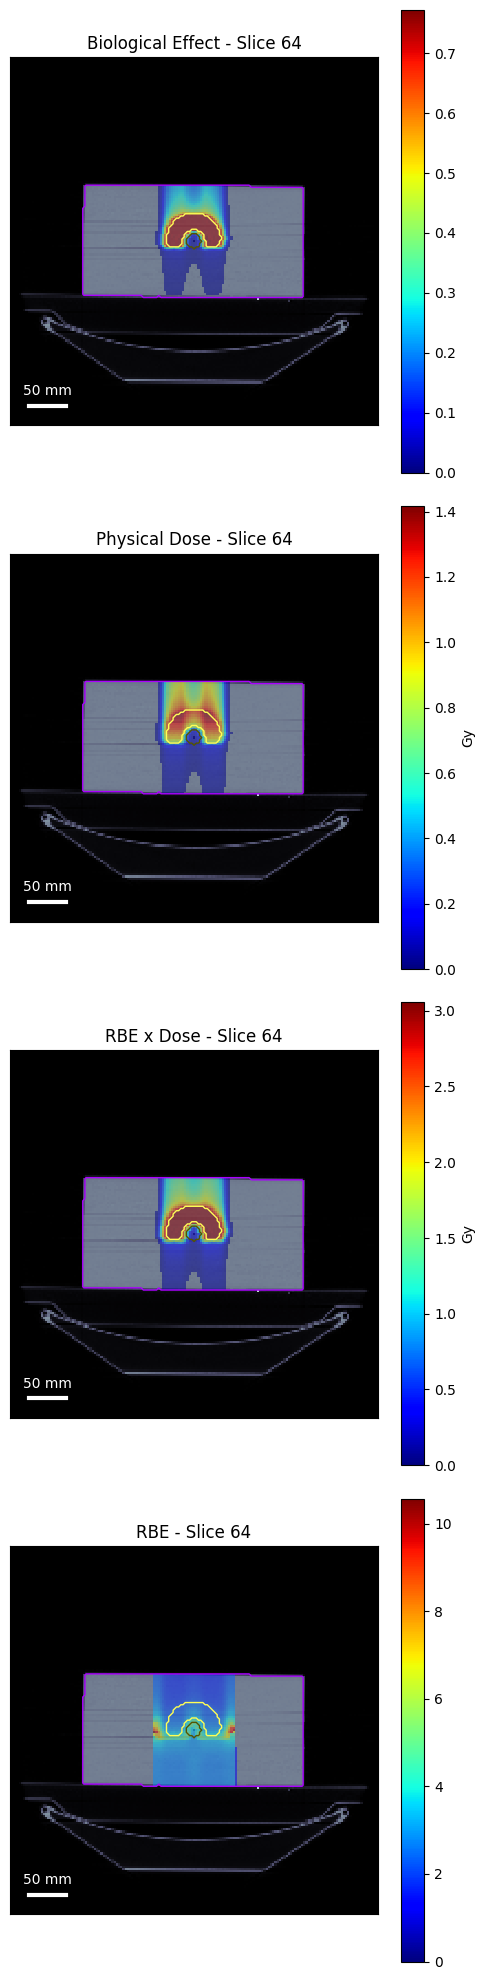

In [7]:
if GUI_AVAILABLE:
    # Use the GUI if [gui] dependencies are installed
    launch_viewer(ct, cst, result)
else:
    # Choose slices to visualize
    view_slice = [int(np.round(ct.size[2] / 2))]

    # Visualize the results
    # Use plot_multiple_slices to visualize the biological effect and physical dose
    # use plot_slice() for single distributions
    plot_multiple_slices(
        image_volume=ct,
        cst=cst,
        overlays=[result["effect"], result["physical_dose"], result["rbe_x_dose"], result["rbe"]],
        view_slice=view_slice,
        plane="axial",
        overlay_unit=["1", "Gy", "Gy", "1"],
        overlay_titles=["Biological Effect", "Physical Dose", "RBE x Dose", "RBE"],
        show_plot=True,
    )